## Import Libraries

In [1]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import cv2
from captum.attr import LayerGradCam
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

## Device Selection

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Dataset Path Finding

In [ ]:
os.listdir('Dataset/Training')

['pituitary', 'notumor', 'meningioma', 'glioma']

In [ ]:
os.listdir('Dataset/Testing')

['pituitary', 'notumor', 'meningioma', 'glioma']

## Dataset Path

In [ ]:
training_dataset_path = 'Dataset/Training'
test_dataset_path = 'Dataset/Testing'

## Getting Mean and Standard Deviation

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [7]:
train_dataset = torchvision.datasets.ImageFolder(
    root=training_dataset_path, 
    transform=transform
)

In [8]:
train_loader = torch.utils.data.DataLoader(
    dataset = train_dataset, 
    batch_size=32, 
    shuffle=False,
    pin_memory=True
)

In [9]:
def get_mean_and_std(loader):
    mean = 0.
    std = 0.
    total_images_count = 0
    
    for images, _ in loader:
        images = images.to(device)
        images_count_in_batch = images.size(0)
        images = images.view(images_count_in_batch, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += images_count_in_batch
        
    mean /= total_images_count
    std /= total_images_count
    
    return mean, std

In [10]:
mean, std = get_mean_and_std(train_loader)

In [11]:
print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: tensor([0.1840, 0.1840, 0.1840], device='cuda:0')
Std: tensor([0.1793, 0.1793, 0.1793], device='cuda:0')


## Preprocessing

In [12]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [13]:
train_dataset = torchvision.datasets.ImageFolder(
    root=training_dataset_path,
    transform=train_transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root=test_dataset_path,
    transform=test_transform
)

In [14]:
def show_transformed_image(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=6, shuffle=True)
    batch = next(iter(loader))
    images, labels = batch
    
    images = images.to(device)
    labels = labels.to(device)
    
    grid = torchvision.utils.make_grid(images, nrow=3)
    grid = grid.cpu()
    
    plt.figure(figsize=(11, 11))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    
    print("Labels:", labels)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0262009..4.1138654].


Labels: tensor([3, 3, 0, 3, 2, 1], device='cuda:0')


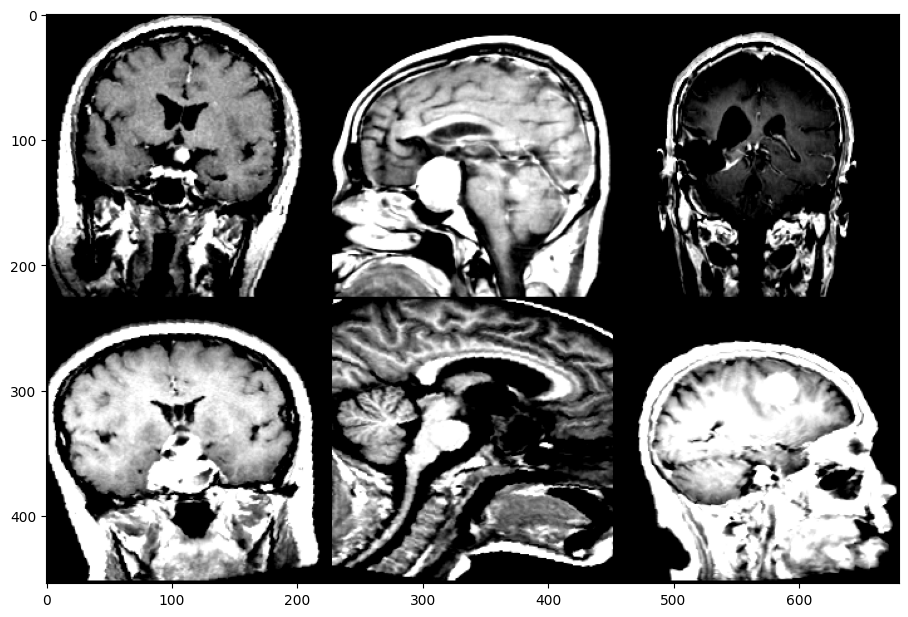

In [15]:
show_transformed_image(train_dataset)

In [16]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
class_names = train_dataset.classes
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


## All Method

In [18]:
def get_model(model_name):
    if model_name == "resnet":
        model = models.resnet50(pretrained=True)

        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, 4)

        # Freeze all
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze last block + classifier
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

        target_layer = model.layer4

    elif model_name == "densenet":
        model = models.densenet121(pretrained=True)
    
        num_features = model.classifier.in_features
        model.classifier = nn.Linear(num_features, 4)
    
        for param in model.parameters():
            param.requires_grad = False
    
        for param in model.features[-1].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True
    
        target_layer = model.features[-1]

    elif model_name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)

        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, 4)

        for param in model.parameters():
            param.requires_grad = False

        for param in model.features[-1].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

        target_layer = model.features[-1]

    elif model_name == "mobilenet":
        model = models.mobilenet_v2(pretrained=True)

        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, 4)

        for param in model.parameters():
            param.requires_grad = False

        for param in model.features[-1].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

        target_layer = model.features[-1]

    return model.to(device), target_layer

In [19]:
def train_model(model, train_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

    return model

In [20]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return acc, all_labels, all_preds

In [21]:
def visualize_integrated_gradients(model, dataset, index=0):
    model.eval()

    ig = IntegratedGradients(model)

    image, label = dataset[index]
    input_img = image.unsqueeze(0).to(device)

    # Enable gradients
    input_img.requires_grad_()

    # Forward pass
    output = model(input_img)
    pred = output.argmax(dim=1).item()

    print(f"True: {class_names[label]}")
    print(f"Pred: {class_names[pred]}")

    baseline = torch.zeros_like(input_img).to(device)

    # Compute attributions
    attributions, delta = ig.attribute(
        input_img,
        baseline,
        target=pred,
        return_convergence_delta=True
    )

    print(f"Convergence delta: {delta.item():.6f}")  

    # Convert to numpy
    original_img_np = np.transpose(image.cpu().detach().numpy(), (1, 2, 0))
    attr_np = np.transpose(attributions.squeeze().cpu().detach().numpy(), (1, 2, 0))

    # Normalize attribution
    attr_np = np.maximum(attr_np, 0)
    if attr_np.max() != 0:
        attr_np /= attr_np.max()

    # Visualization
    viz.visualize_image_attr(
        attr_np,
        original_img_np,
        method='blended_heat_map',
        cmap='jet',
        show_colorbar=True,
        sign='positive',
        title=f"Integrated Gradients (Pred: {class_names[pred]})"
    )

In [22]:
def visualize_gradcam(model, target_layer, dataset, index=0):
    model.eval()

    gradcam = LayerGradCam(model, target_layer)

    image, label = dataset[index]
    input_img = image.unsqueeze(0).to(device)

    output = model(input_img)
    pred = output.argmax(dim=1).item()

    print(f"True: {class_names[label]}")
    print(f"Pred: {class_names[pred]}")

    attribution = gradcam.attribute(input_img, target=pred)

    heatmap = attribution.squeeze().cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)

    if heatmap.max() != 0:
        heatmap /= heatmap.max()

    heatmap = cv2.resize(heatmap, (224, 224))

    original = image.permute(1, 2, 0).cpu().numpy()
    original = (original - original.min()) / (original.max() - original.min())

    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = np.float32(heatmap_colored) / 255

    overlay = heatmap_colored * 0.4 + original

    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

## Training & Testing

In [23]:
model_names = ["resnet", "densenet", "efficientnet", "mobilenet"]
results = {}

for name in model_names:
    print(f"\n===== Training {name.upper()} =====")

    model, target_layer = get_model(name)

    model = train_model(model, train_loader, epochs=10)

    acc, y_true, y_pred = evaluate_model(model, test_loader)

    results[name] = {
        "model": model,
        "accuracy": acc,
        "target_layer": target_layer
    }

    print(f"{name} Accuracy: {acc:.2f}%")


===== Training RESNET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] Loss: 0.2966
Epoch [2/10] Loss: 0.1354
Epoch [3/10] Loss: 0.0895
Epoch [4/10] Loss: 0.0628
Epoch [5/10] Loss: 0.0560
Epoch [6/10] Loss: 0.0465
Epoch [7/10] Loss: 0.0445
Epoch [8/10] Loss: 0.0367
Epoch [9/10] Loss: 0.0341
Epoch [10/10] Loss: 0.0272
resnet Accuracy: 93.69%

===== Training DENSENET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] Loss: 1.1884
Epoch [2/10] Loss: 0.8901
Epoch [3/10] Loss: 0.7368
Epoch [4/10] Loss: 0.6521
Epoch [5/10] Loss: 0.5881
Epoch [6/10] Loss: 0.5471
Epoch [7/10] Loss: 0.5153
Epoch [8/10] Loss: 0.4855
Epoch [9/10] Loss: 0.4708
Epoch [10/10] Loss: 0.4642
densenet Accuracy: 80.19%

===== Training EFFICIENTNET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] Loss: 0.8671
Epoch [2/10] Loss: 0.5005
Epoch [3/10] Loss: 0.4078
Epoch [4/10] Loss: 0.3639
Epoch [5/10] Loss: 0.3442
Epoch [6/10] Loss: 0.3125
Epoch [7/10] Loss: 0.2930
Epoch [8/10] Loss: 0.2875
Epoch [9/10] Loss: 0.2669
Epoch [10/10] Loss: 0.2639
efficientnet Accuracy: 86.12%

===== Training MOBILENET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] Loss: 0.6357
Epoch [2/10] Loss: 0.3804
Epoch [3/10] Loss: 0.3330
Epoch [4/10] Loss: 0.3119
Epoch [5/10] Loss: 0.2842
Epoch [6/10] Loss: 0.2663
Epoch [7/10] Loss: 0.2565
Epoch [8/10] Loss: 0.2426
Epoch [9/10] Loss: 0.2343
Epoch [10/10] Loss: 0.2257
mobilenet Accuracy: 86.50%


## Explainable AI

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4].



===== Explainability for RESNET =====

--- Grad-CAM ---
True: glioma
Pred: notumor


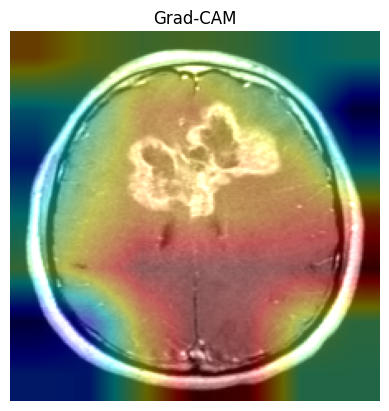


--- Integrated Gradients ---
True: glioma
Pred: notumor
Convergence delta: 1.127877


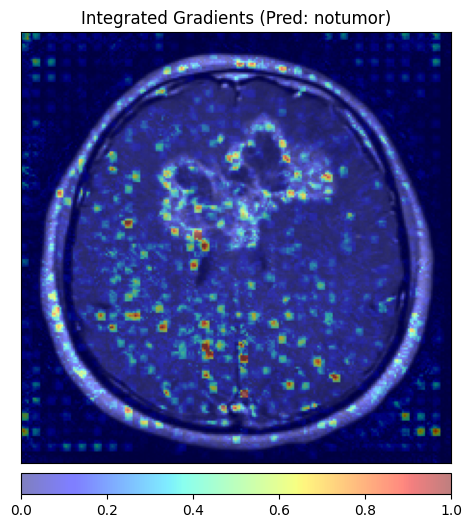

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4].



===== Explainability for DENSENET =====

--- Grad-CAM ---
True: glioma
Pred: notumor


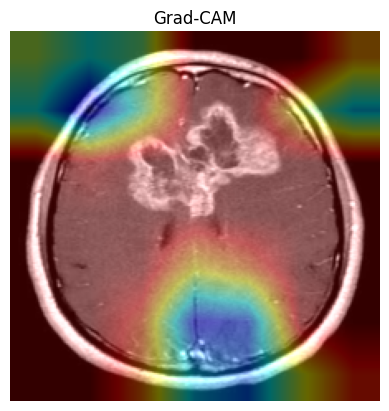


--- Integrated Gradients ---
True: glioma
Pred: notumor
Convergence delta: -0.025181


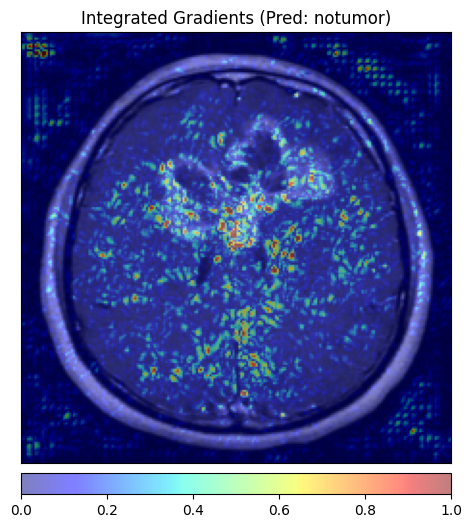

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.392126].



===== Explainability for EFFICIENTNET =====

--- Grad-CAM ---
True: glioma
Pred: glioma


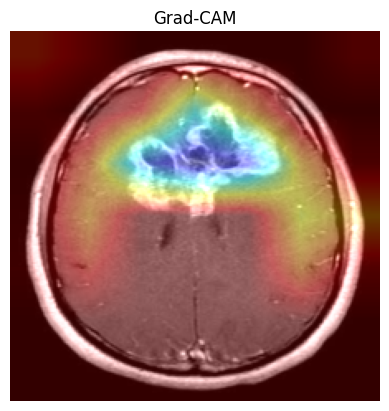


--- Integrated Gradients ---
True: glioma
Pred: glioma
Convergence delta: -10.255099


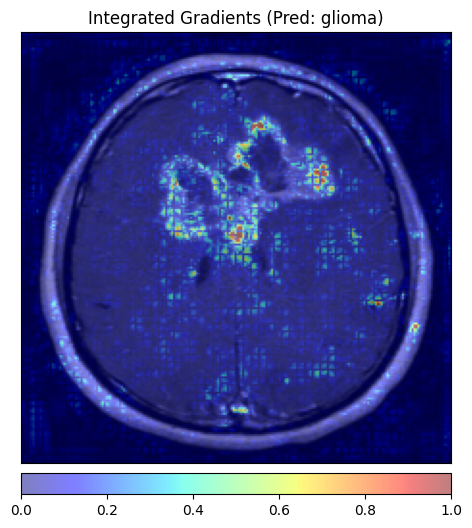

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.388189].



===== Explainability for MOBILENET =====

--- Grad-CAM ---
True: glioma
Pred: meningioma


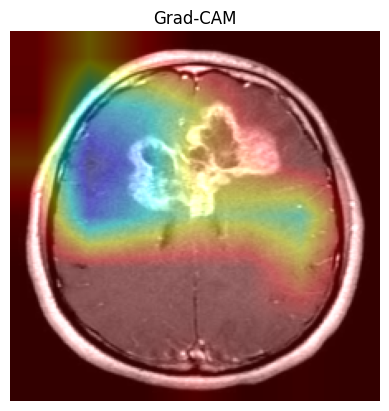


--- Integrated Gradients ---
True: glioma
Pred: meningioma
Convergence delta: 0.903814


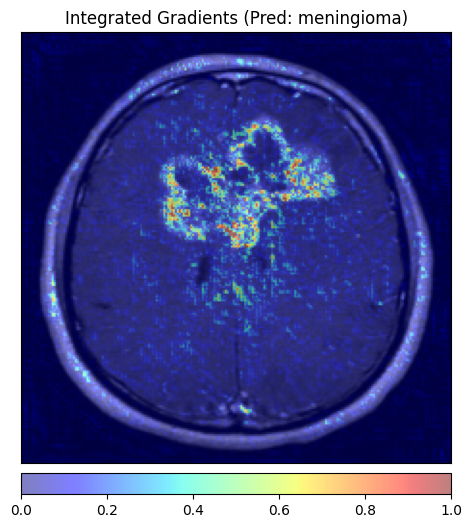

In [24]:
for name in results:
    print(f"\n===== Explainability for {name.upper()} =====")

    model = results[name]["model"]
    target_layer = results[name]["target_layer"]

    print("\n--- Grad-CAM ---")
    visualize_gradcam(model, target_layer, test_dataset)

    print("\n--- Integrated Gradients ---")
    visualize_integrated_gradients(model, test_dataset)